In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, roc_auc_score, precision_recall_curve

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("creditcard.csv")
print("Dataset loaded successfully")
print("Shape of dataset (rows, columns)",df.shape)

Dataset loaded successfully
Shape of dataset (rows, columns) (284807, 31)


In [3]:
#EDA
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Getting the summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
#Finding the basic statistics
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
#confirm is their are missing values
print("Missing values per coulmn")
print(df.isnull().sum())

Missing values per coulmn
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


The data set is clean

In [7]:
#class imbalance check
#count of how many transactions are normal vs fraud

class_counts = df['Class'].value_counts()
print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
#Percentage of fraud cases
fraud_percentage = (class_counts[1]/class_counts.sum()) * 100
print(f"Fraud cases make up only {fraud_percentage:.4f}% of the dataset")

Fraud cases make up only 0.1727% of the dataset


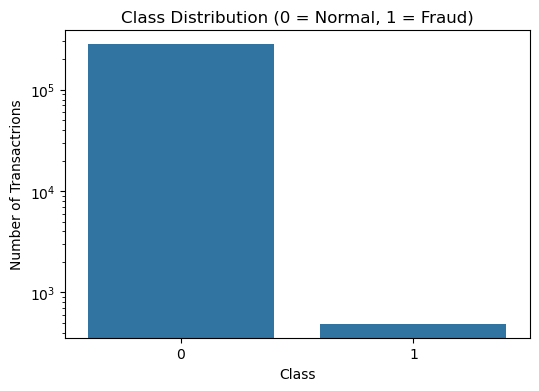

In [9]:
#Visualization of the imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.xlabel("Class")
plt.ylabel("Number of Transactrions")
plt.yscale('log')
plt.show()

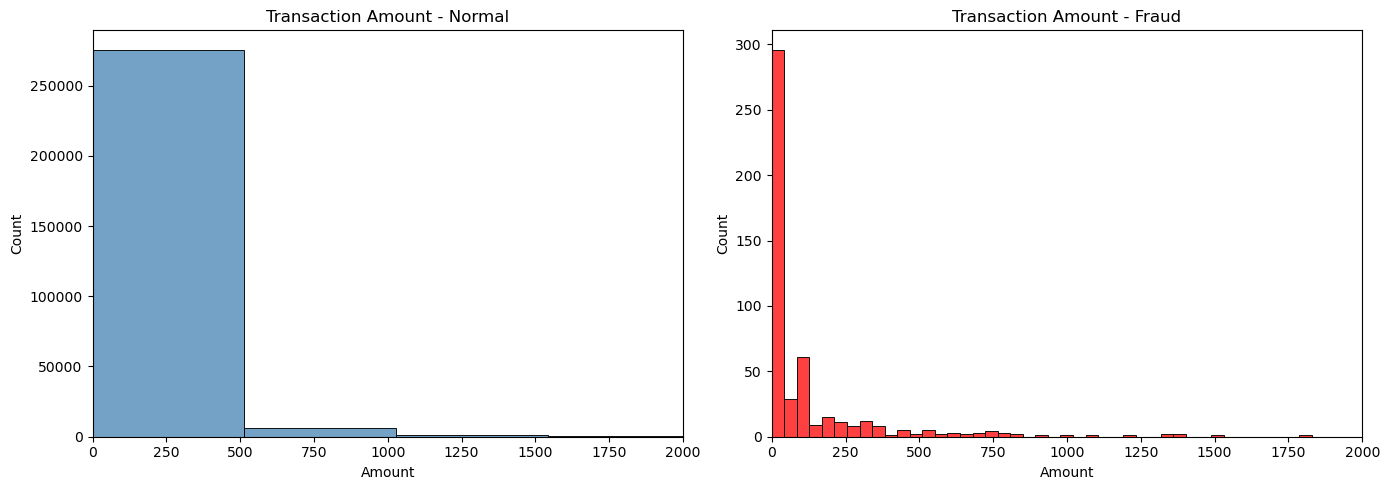

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [10]:
#comparing transaction amounts: normal vs fraud
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[df['Class']==0]['Amount'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title("Transaction Amount - Normal")
axes[0].set_xlim(0, 2000)

sns.histplot(df[df['Class']==1]['Amount'], bins=50, ax=axes[1], color='red')
axes[1].set_title("Transaction Amount - Fraud")
axes[1].set_xlim(0, 2000)

plt.tight_layout()
plt.show()

#print summary statistics for amount, grouped by class
print(df.groupby('Class')['Amount'].describe())

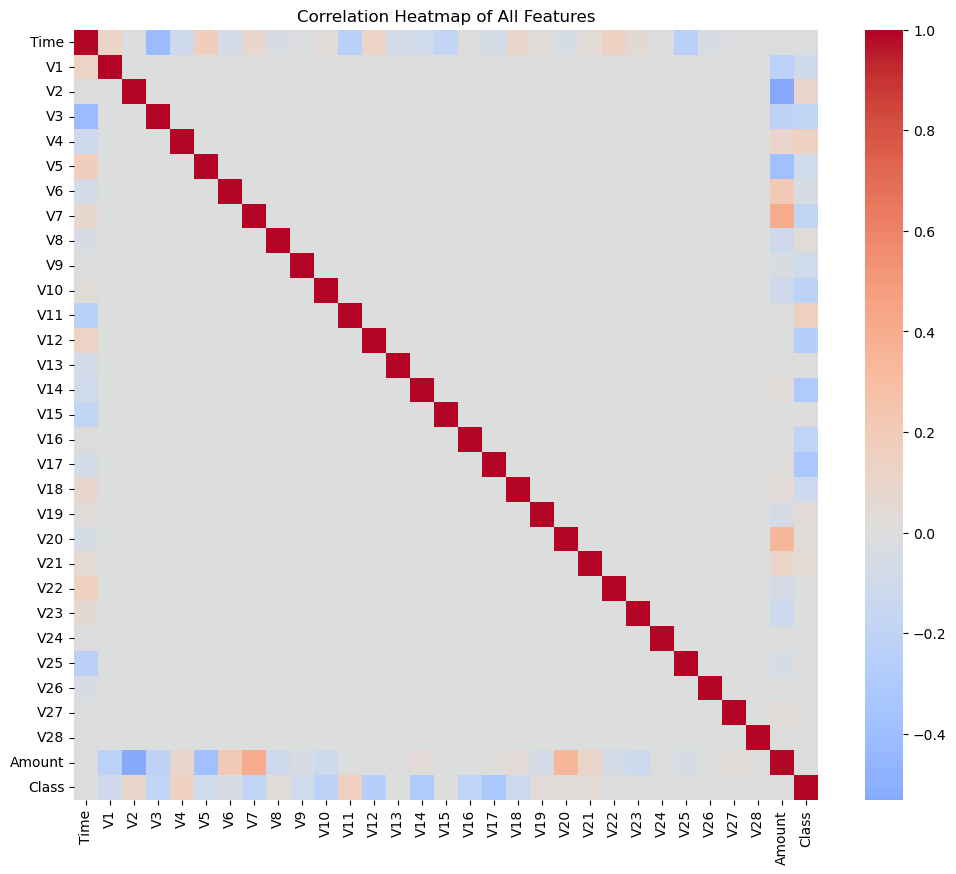

In [11]:
#Correlation Heatmap
plt.figure(figsize=(12,10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, cbar=True)
plt.title("Correlation Heatmap of All Features")
plt.show()

In [12]:
# Data Propressing
# Scale 'Amount' and 'Time'\

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

df['Time_scaled'] = scaler.fit_transform(df[['Time']])

In [13]:
#Dropping the orignal unscaled columns
df = df.drop(['Amount', 'Time'], axis=1)

print("Scaling complete. New columns added: Amount_scaled, Time_scaled")
df.head()

Scaling complete. New columns added: Amount_scaled, Time_scaled


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [14]:
#Seperating feature (X) from the label (y)

X = df.drop('Class', axis=1)
y = df['Class']

print("Features shape (X)",  X.shape)
print("Labels shape (y)", y.shape)

Features shape (X) (284807, 30)
Labels shape (y) (284807,)


In [15]:
#Train and test

X_train, X_test, y_train, y_test = train_test_split(
X,y,
test_size=0.2,
random_state=42,
stratify=y
)
print("Training set size", X_train.shape)
print("Test set size", X_test.shape)
print("Fraud cases in training set", y_train.sum())
print("Fraud cases in test set", y_test.sum())


Training set size (227845, 30)
Test set size (56962, 30)
Fraud cases in training set 394
Fraud cases in test set 98


In [32]:
# Dictionary to store results from each model for final comparison

results = {}

def evaluate_model(model_name, y_true, y_pred, y_scores=None):
    print(f"\===== {model_name} =====")
    
    #Confusion Matrix
    print("Confusion Matrix")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print("Rows = Actual, Columns = Predicted | Order: Normal, Fraud")
    
    #Classification Report
    print("\nClassification Report")
    print(classification_report(y_true, y_pred, target_names=["Normal", "Fraud"]))

    #Precision, Recall, F1 for Fraud class
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', pos_label=1
    )
    
    #ROC-AUC
    roc_auc = None
    if y_scores is not None:
        roc_auc = roc_auc_score(y_true, y_scores)
        print(f"ROC-AUC Score:{roc_auc:.4f}")
        
        # Store the results
        results[model_name] = {
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "ROC-AUC": roc_auc,
        }
        
        return results[model_name]
        

In [33]:
#Isolation Forest

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.0017,
    random_state=42,
    n_jobs=-1
)

#Fit on training data
iso_forest.fit(X_train)

print("Isolation Forest trained successfully")

Isolation Forest trained successfully


In [34]:
# Make prediction on the TEST set
raw_predictions = iso_forest.predict(X_test)

#convert to match the label format: 1=fraud, 0=normal points
y_pred_iso = np.where(raw_predictions == -1, 1, 0)

# multiply by -1 so that HIGHER score = MORE anomalous, matching y_true=1 for fraud
y_scores_iso = - iso_forest.score_samples(X_test)

#Evaluate
evaluate_model("Isolate Forest(Tuned)", y_test, y_pred_iso, y_scores_iso)

\===== Isolate Forest(Tuned) =====
Confusion Matrix
[[56792    72]
 [   66    32]]
Rows = Actual, Columns = Predicted | Order: Normal, Fraud

Classification Report
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.31      0.33      0.32        98

    accuracy                           1.00     56962
   macro avg       0.65      0.66      0.66     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score:0.9536


{'Precision': 0.3076923076923077,
 'Recall': 0.32653061224489793,
 'F1-Score': 0.31683168316831684,
 'ROC-AUC': np.float64(0.9536498828569131)}

In [35]:
#Trying different contamination values
contamination_values = [0.001, 0.0017, 0.005, 0.01]
tuning_results = []
for c in contamination_values:
    model = IsolationForest(n_estimators=100, contamination=c, random_state=42, n_jobs=-1
                           )
    model.fit(X_train)

    preds = model.predict(X_test)
    y_pred = np.where(preds == -1, 1, 0)

    precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='binary', pos_label=1, zero_division=0
    )

    tuning_results.append({
    "contamination": c,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
    })

print(f"conatmination={c:<8} -> Precision:{precision:.4f}, Recall:{recall:.4f}, F1:{f1:.4f}")
#Display as table
tuning_df = pd.DataFrame(tuning_results) 
print("\n=== Final Tuning Results Summary ===") 
display(tuning_df.round(4))
    

conatmination=0.01     -> Precision:0.1013, Recall:0.6224, F1:0.1743

=== Final Tuning Results Summary ===


,contamination,Precision,Recall,F1-Score
0,0.0010,0.3529,0.2449,0.2892
1,0.0017,0.3077,0.3265,0.3168
2,0.0050,0.1634,0.5102,0.2475
3,0.0100,0.1013,0.6224,0.1743


In [37]:
#Taking the NORMAL transactions from the training set due how large the dataset is for One-Class SVM
X_train_normal = X_train[y_train == 0]

#Smaller subset random sample for 0ne-Class SVM traing (for speed)
sample_size = 5000
X_train_sample = X_train_normal.sample(n=sample_size, random_state=42)

print(f"Training One-Class SVM on a sample of {sample_size} normal transaction...")

Training One-Class SVM on a sample of 5000 normal transaction...


In [38]:
oc_svm = OneClassSVM(
    kernel='rbf',
    gamma='auto',
    nu=0.0017
)

oc_svm.fit(X_train_sample)

print("One-Class SVM trained successfully")

One-Class SVM trained successfully


In [39]:
#Prediction
raw_predictions_svm = oc_svm.predict(X_test)
y_pred_svm = np.where(raw_predictions_svm == -1, 1, 0)

#Scores (higher = more fraudulent/anomalous)
y_scores_svm = -oc_svm.decision_function(X_test)

#Evaluate
evaluate_model("One-Class SVM", y_test, y_pred_svm, y_scores_svm)

\===== One-Class SVM =====
Confusion Matrix
[[53686  3178]
 [   11    87]]
Rows = Actual, Columns = Predicted | Order: Normal, Fraud

Classification Report
              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97     56864
       Fraud       0.03      0.89      0.05        98

    accuracy                           0.94     56962
   macro avg       0.51      0.92      0.51     56962
weighted avg       1.00      0.94      0.97     56962

ROC-AUC Score:0.9451


{'Precision': 0.02664624808575804,
 'Recall': 0.8877551020408163,
 'F1-Score': 0.05173951828724353,
 'ROC-AUC': np.float64(0.9451150184328093)}

In [40]:
#Autoenconder
input_dim = X_train.shape[1]

print(f"Number of input features: {input_dim}" )

#Input layer
input_layer = Input(shape=(input_dim,))

#Encoder: compression
encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(8, activation='relu')(encoded)

#Decoder: reconstruction
decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

#Full autoencoder model
autoencoder = Model(inputs=input_layer, outputs=decoded)

#Compiling adam optimizer, mse measures reconstruction
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Number of input features: 30


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286 (5.02 KB)

 Trainable params: 1,286 (5.02 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
#training the autoencoder on NORMAL transactions only
X_train_normal_full = X_train[y_train == 0]

history = autoencoder.fit(
    X_train_normal_full, X_train_normal_full,
    epochs=10,
    batch_size=256,
shuffle=True,
validation_split=0.1,
verbose=1
)

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.7066 - val_loss: 0.4671
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4197 - val_loss: 0.3714
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3678 - val_loss: 0.3469
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3475 - val_loss: 0.3309
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3342 - val_loss: 0.3213
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3261 - val_loss: 0.3142
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3206 - val_loss: 0.3105
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3173 - val_loss: 0.3074
Epoch 9/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3123 - val_loss: 0.3181
Epoch 10/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3083 - val_loss: 0.2984


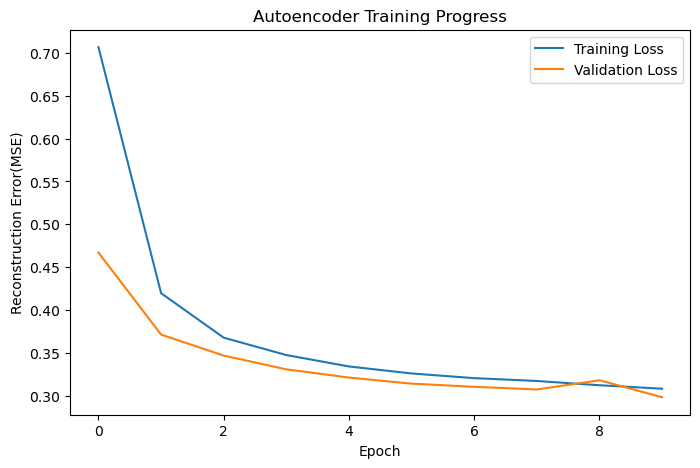

In [42]:
#Using plot training/validation loss to check learning progress
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Autoencoder Training Progress")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Error(MSE)")
plt.legend()
plt.show()

In [43]:
#Getting reconstruction for the test set
X_test_reconstructed = autoencoder.predict(X_test, verbose=0)

#Reconstruction error per 
reconstruction_errors = np.mean(np.square(X_test.values - X_test_reconstructed), axis=1)

#Setting standard threshold based on the expected contamination rate (top 0.17% highest errors)
threshold = np.percentile(reconstruction_errors, 100 - 0.17)

print(f"Reconstruction error threshold: {threshold:.4f}")

#flaging anomalies
y_pred_ae = np.where(reconstruction_errors > threshold, 1, 0)

#Reconstruction error serving as the anomaly score for ROC-AUC
y_scores_ae = reconstruction_errors
evaluate_model("Autoencoder", y_test, y_pred_ae, y_scores_ae)

Reconstruction error threshold: 9.0550
\===== Autoencoder =====
Confusion Matrix
[[56816    48]
 [   49    49]]
Rows = Actual, Columns = Predicted | Order: Normal, Fraud

Classification Report
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.51      0.50      0.50        98

    accuracy                           1.00     56962
   macro avg       0.75      0.75      0.75     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score:0.9705


{'Precision': 0.5051546391752577,
 'Recall': 0.5,
 'F1-Score': 0.5025641025641026,
 'ROC-AUC': np.float64(0.9704621050727549)}

In [44]:
#Comparison DataFrame
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.round(4)

print(comparison_df)

                       Precision  Recall  F1-Score  ROC-AUC
Isolate Forest(Tuned)     0.3077  0.3265    0.3168   0.9536
One-Class SVM             0.0266  0.8878    0.0517   0.9451
Autoencoder               0.5052  0.5000    0.5026   0.9705


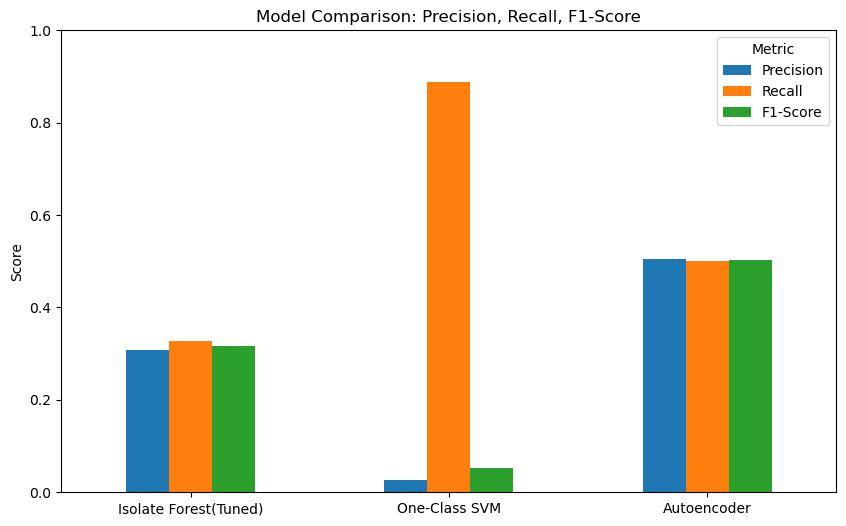

In [45]:
#Visualising comparison as a grouped bar chart
metrics = ['Precision','Recall', 'F1-Score']
comparison_df[metrics].plot(
    kind='bar',
    figsize=(10,6),
    rot=0
)

plt.title("Model Comparison: Precision, Recall, F1-Score")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.show()

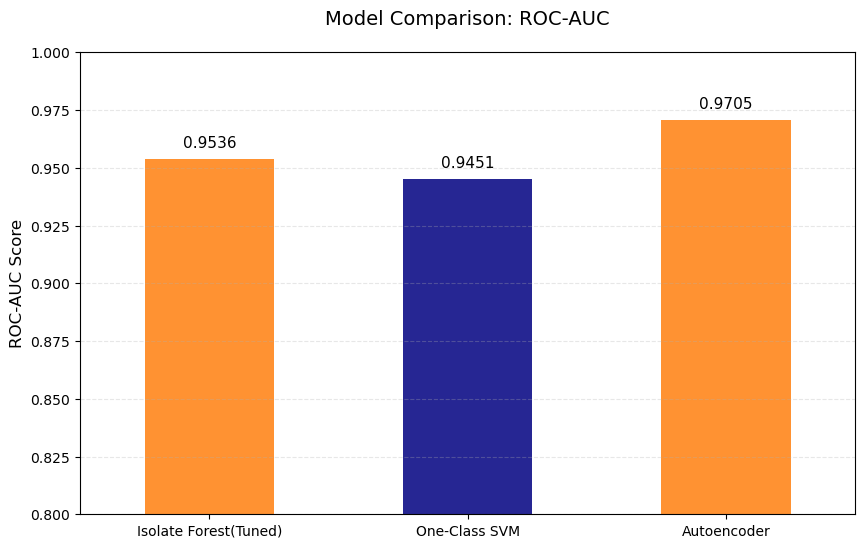

In [56]:
#Seperate chart for ROC-AUC
comparison_df['ROC-AUC'].plot(
    kind='bar',
    figsize=(10,6),
    color=['#ff7f0e', '#000080'],
    rot=0,
    alpha=0.85
)

plt.title("Model Comparison: ROC-AUC", fontsize=14, pad=20)
plt.ylabel("ROC-AUC Score", fontsize=12)
plt.ylim(0.8, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

#Adding value labels on top of bars
for i, v in enumerate(comparison_df['ROC-AUC']):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontsize=11)

plt.show()
